In [45]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import os

# 2026-04-18

## Test plots: histogram of folding times

In [2]:
data = np.loadtxt('long_seq_51_100_nt/length_51/18871197_1018_output2024_06_27_12_09_55__2.csv',
                  delimiter=',', usecols=2)
print(data.shape)

(1000,)


In [3]:
seq = np.loadtxt('long_seq_51_100_nt/length_51/18871197_1018_output2024_06_27_12_09_55__2.csv',
                 delimiter=',', usecols=4, max_rows=1, dtype=str)
print(seq)

CGUGCUUCGAUUAAACGACUCGAAACAGCGAGGCUUUCCUGACUAACACCU


(array([  4.,  11.,  12.,  11.,  16.,   8.,   3.,   2.,   1.,   2.,   3.,
          2.,   5.,   5.,   5.,  13.,  21.,  24.,  38.,  46.,  63.,  60.,
         76., 106., 126., 105., 102.,  77.,  42.,  11.]),
 array([ 0.19062036,  0.62325066,  1.05588096,  1.48851125,  1.92114155,
         2.35377185,  2.78640215,  3.21903245,  3.65166274,  4.08429304,
         4.51692334,  4.94955364,  5.38218394,  5.81481423,  6.24744453,
         6.68007483,  7.11270513,  7.54533543,  7.97796572,  8.41059602,
         8.84322632,  9.27585662,  9.70848692, 10.14111721, 10.57374751,
        11.00637781, 11.43900811, 11.87163841, 12.3042687 , 12.736899  ,
        13.1695293 ]),
 <BarContainer object of 30 artists>)

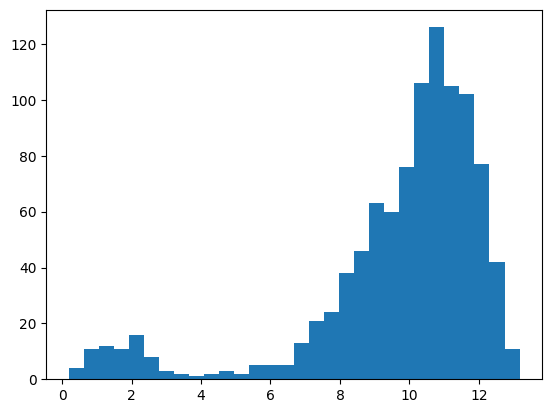

In [4]:
plt.hist(np.log(data), bins=30)

In [5]:
dir = Path('long_seq_51_100_nt/length_51')

for file in dir.iterdir():
    if file.is_file():
        print(file.name)
        #print(Path(file).resolve())

18871197_1018_output2024_06_27_12_09_55__2.csv
18871197_1435_output2024_06_25_16_45_45__1.csv
18871197_204_output2024_06_24_02_51_45__1.csv
18871197_465_output2024_06_24_03_13_07__0.csv
18871197_946_output2024_06_24_04_13_13__0.csv


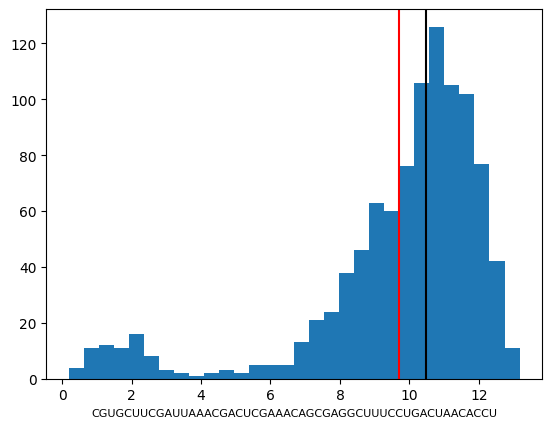

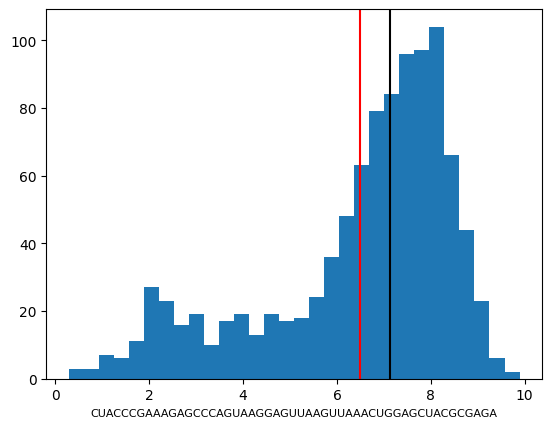

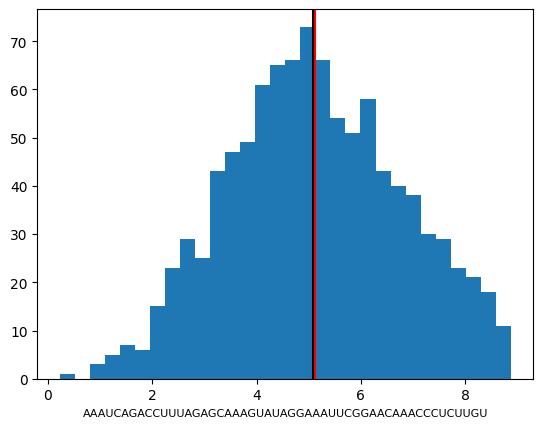

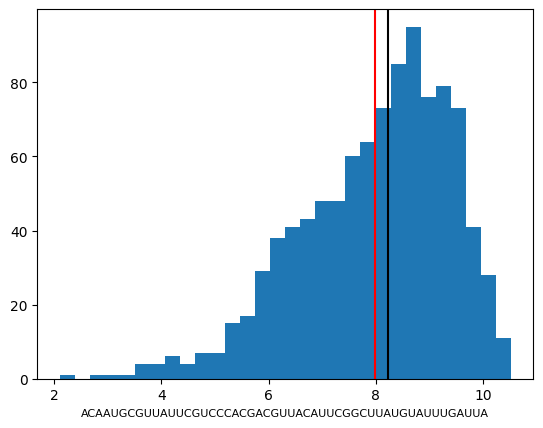

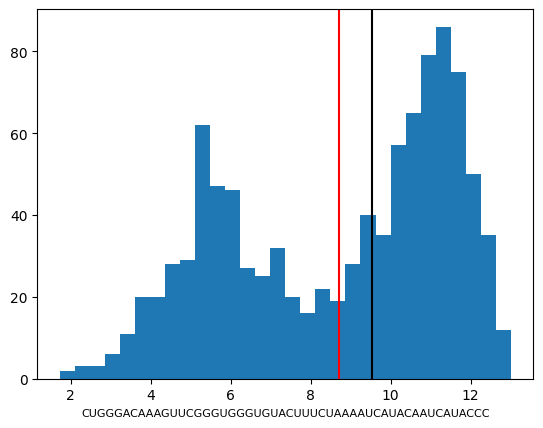

In [6]:
dir = Path('long_seq_51_100_nt/length_51')

for file in dir.iterdir():
    if file.is_file():
        data = np.loadtxt(Path(file).resolve(), delimiter=',', usecols=2)
        seq = np.loadtxt(Path(file).resolve(), delimiter=',', usecols=4, max_rows=1, dtype=str)
        plt.xlabel(seq, fontsize=8)
        plt.hist(np.log(data), bins=30)
        plt.axvline(np.mean(np.log(data)),color='red')
        plt.axvline(np.median(np.log(data)),color='black')
        plt.show()

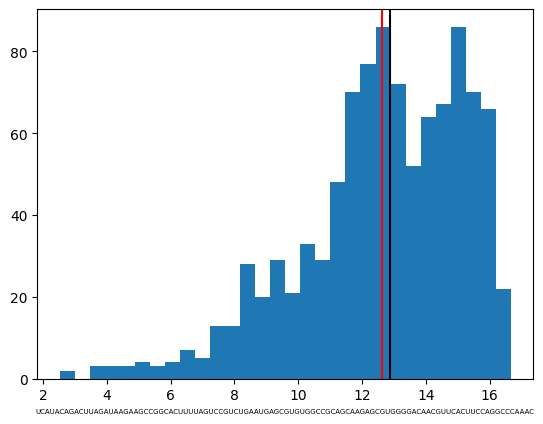

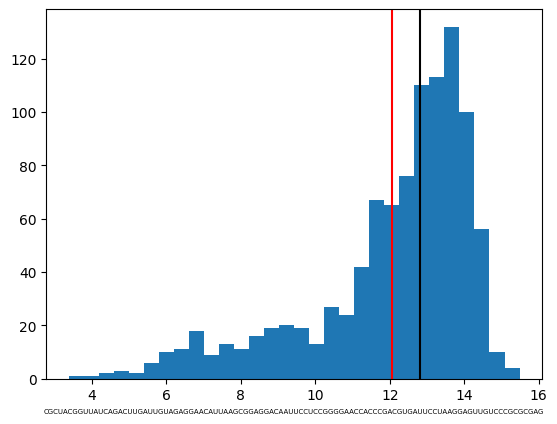

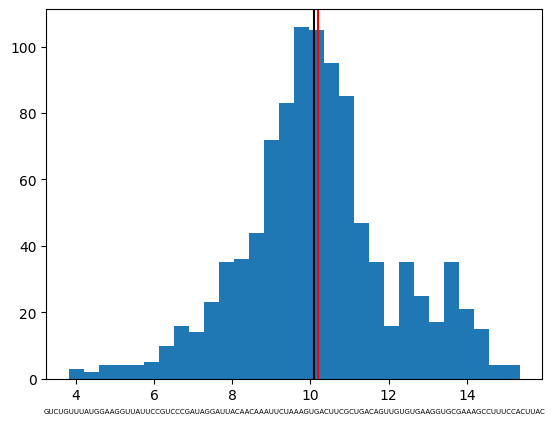

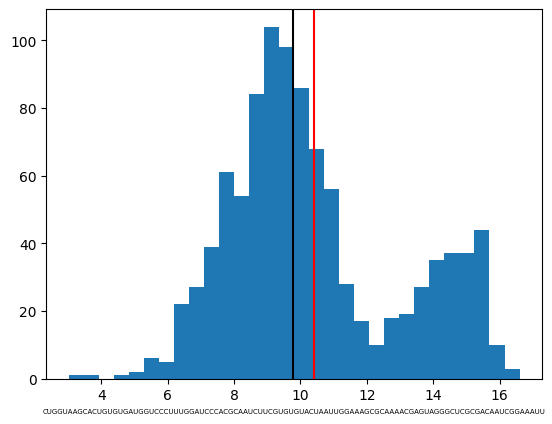

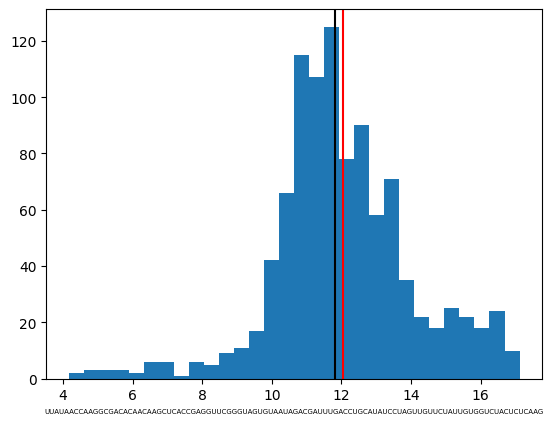

In [7]:
dir = Path('long_seq_51_100_nt/length_100')

for file in dir.iterdir():
    if file.is_file():
        data = np.loadtxt(Path(file).resolve(), delimiter=',', usecols=2)
        seq = np.loadtxt(Path(file).resolve(), delimiter=',', usecols=4, max_rows=1, dtype=str)
        plt.xlabel(seq, fontsize=5)
        plt.hist(np.log(data), bins=30)
        plt.axvline(np.mean(np.log(data)),color='red')
        plt.axvline(np.median(np.log(data)),color='black')
        plt.show()

## Folding time vs length of RNA sequence

In [3]:
dir = Path('.')

counter = 0
for file in dir.rglob('*'):
    if file.is_file() and file.parent != dir:
        counter += 1
        
print(counter)

635


In [4]:
dir = Path('.')

arr_seqlength = [] # sequence length
arr_medlogfpt = [] # median log fpt (first passage time)

for file in dir.rglob('*'):
    if file.is_file() and file.parent != dir:
        data = np.loadtxt(Path(file).resolve(), delimiter=',', usecols=2)
        log_data = np.log(data)
        seq = str(np.loadtxt(Path(file).resolve(), delimiter=',', usecols=4, max_rows=1, dtype=str))

        arr_seqlength.append(len(seq))
        arr_medlogfpt.append(np.median(log_data))

arr_seqlength = np.array(arr_seqlength)
arr_medlogfpt = np.array(arr_medlogfpt)

C:\Users\Julius\AppData\Local\Temp\ipykernel_178816\3802590888.py:9: RuntimeWarning: divide by zero encountered in log
  log_data = np.log(data)


Text(0, 0.5, 'Median log FPT (first passage time)')

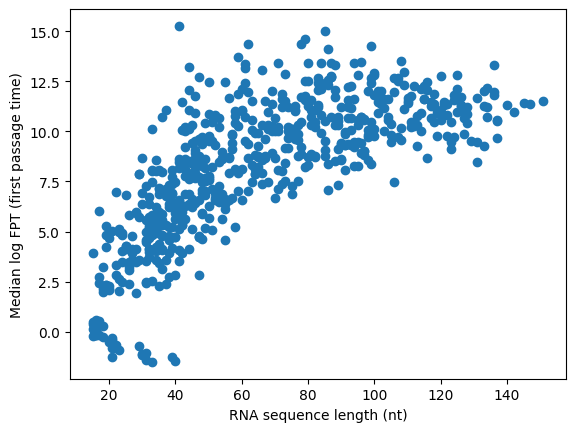

In [10]:
fig, ax = plt.subplots()

ax.scatter(arr_seqlength, arr_medlogfpt)
ax.set_xlabel('RNA sequence length (nt)')
ax.set_ylabel('Median log FPT (first passage time)')


Text(0, 0.5, 'Exp[Median log FPT (first passage time)]')

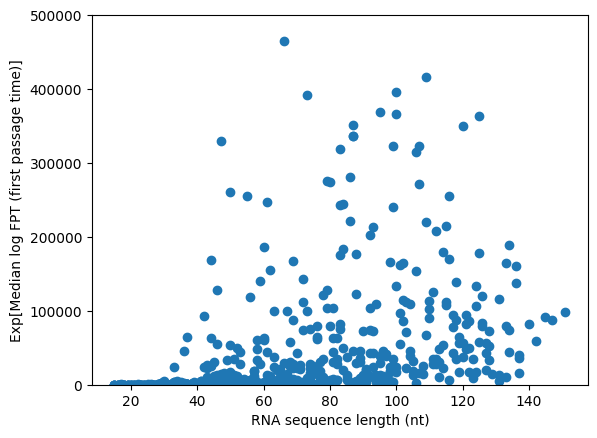

In [11]:
fig, ax = plt.subplots()

ax.scatter(arr_seqlength, np.exp(arr_medlogfpt))
ax.set_ylim(0,5e5)
ax.set_xlabel('RNA sequence length (nt)')
ax.set_ylabel('Exp[Median log FPT (first passage time)]')


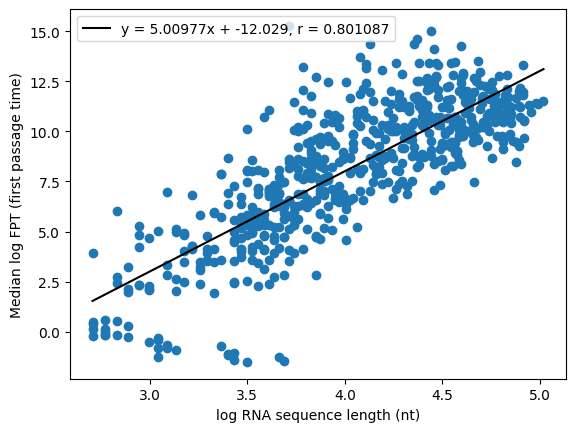

In [12]:
fig, ax = plt.subplots()

arr_logseqlength = np.log(arr_seqlength)
ax.scatter(arr_logseqlength, arr_medlogfpt)
ax.set_xlabel('log RNA sequence length (nt)')
ax.set_ylabel('Median log FPT (first passage time)')

slope, intercept = np.polyfit(arr_logseqlength, arr_medlogfpt, 1)

y = arr_medlogfpt
y_hat = slope*arr_logseqlength + intercept
y_bar = np.mean(y)
sse = np.sum((y - y_hat)**2) # sum of squared errors
sst = np.sum((y - y_bar)**2) # sum of squares total
r2 = 1 - (sse / sst)
r = np.sqrt(r2)

ax.plot(np.array([min(arr_logseqlength), max(arr_logseqlength)]),
        slope*np.array([min(arr_logseqlength), max(arr_logseqlength)]) + intercept,
        color='black', label=f'y = {slope:.6g}x + {intercept:.6g}, r = {r:.6g}')
ax.legend()

# 2026-04-19

In [46]:
dir = Path('.')

min_log_fpt = 0
max_log_fpt = 0

for file in dir.rglob('*'):
    if file.is_file() and file.parent != dir:
        data = np.loadtxt(Path(file).resolve(), delimiter=',', usecols=2)

        where_data_zero = np.where(data == 0)[0]
        if len(where_data_zero) != 0:
            print(file.parent, file.name, where_data_zero)
        
        where_data_nonzero = np.where(data != 0)[0]
        log_data = np.log(data[where_data_nonzero])
        
        seq = str(np.loadtxt(Path(file).resolve(), delimiter=',', usecols=4, max_rows=1, dtype=str))

        min_log_fpt = min(min(log_data), min_log_fpt)
        max_log_fpt = max(max(log_data), min_log_fpt)

print(f'Min log FPT: {min_log_fpt}, Max log FPT: {max_log_fpt}')

short_seq_15_30_nt\length_15 output2024_08_19_12_52_49__698.csv [560]
short_seq_15_30_nt\length_16 output2024_08_19_12_53_30__702.csv [11]
short_seq_15_30_nt\length_17 output2024_08_19_12_05_02__626.csv [389]
short_seq_15_30_nt\length_18 output2024_08_18_03_06_21__73.csv [ 66 250 625 641]
short_seq_15_30_nt\length_20 output2024_08_19_03_59_08__354.csv [903]
short_seq_15_30_nt\length_21 output2024_08_17_21_27_59__28.csv [420 612]
short_seq_15_30_nt\length_21 output2024_08_19_00_01_53__228.csv [230]
short_seq_15_30_nt\length_21 output2024_08_19_12_53_38__704.csv [276 306 452 783]
short_seq_15_30_nt\length_23 output2024_08_19_08_04_49__429.csv [ 40 141 432 792]
short_seq_15_30_nt\length_30 output2024_08_19_04_04_57__374.csv [643]
middle_seq_31_50_nt\length_31 output2024_06_22_14_43_45__274.csv [81]
middle_seq_31_50_nt\length_31 output2024_08_19_08_04_50__436.csv [180]
middle_seq_31_50_nt\length_33 output2024_07_08_02_22_58__180.csv [186 211 222 408 472 555 965]
middle_seq_31_50_nt\length_

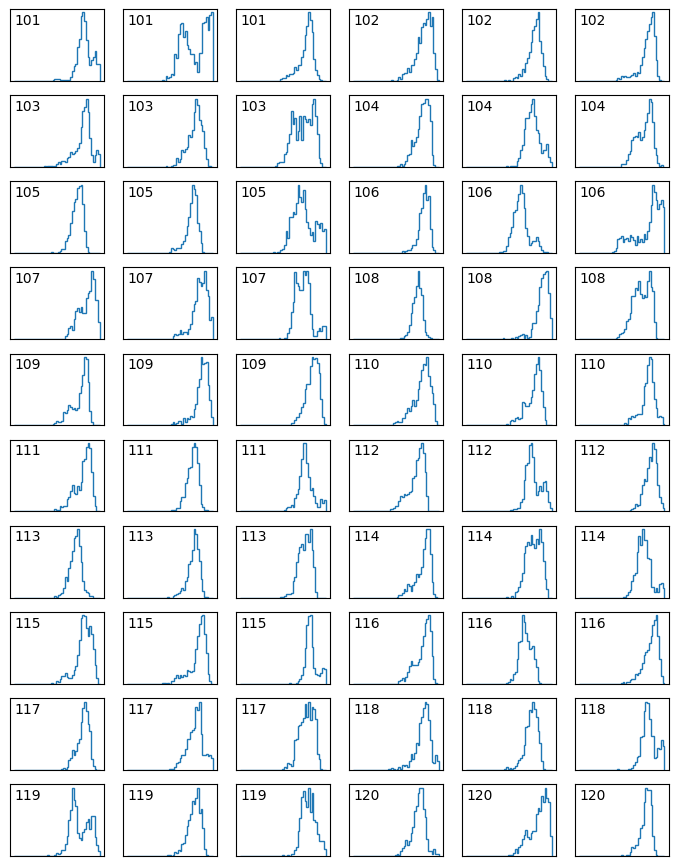

In [58]:
dir = Path('.')

num_bins = 50
binedges_log_fpt = np.linspace(min_log_fpt, max_log_fpt, num_bins)

width_inch = 8.5
height_inch = 11
n_x = 6
n_y = 10
fig, axs = plt.subplots(n_y, n_x, figsize=(width_inch, height_inch))
#plt.tight_layout(pad=1.0)

counter = 0
for file in dir.rglob('*'):
    if file.is_file() and file.parent != dir:
        data = np.loadtxt(Path(file).resolve(), delimiter=',', usecols=2)

        where_data_nonzero = np.where(data != 0)[0]
        log_data = np.log(data[where_data_nonzero])
        
        seq = str(np.loadtxt(Path(file).resolve(), delimiter=',', usecols=4, max_rows=1, dtype=str))

        hist_log_fpt, _ = np.histogram(log_data, binedges_log_fpt, density=True)
        
        i_x = counter % n_x
        i_y = int(counter/n_x)

        ax = axs[i_y][i_x]
        ax.stairs(hist_log_fpt, binedges_log_fpt)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.text(0.05, 0.95, str(len(seq)), transform=ax.transAxes, verticalalignment='top')

        counter += 1
        if counter == n_x*n_y:
            break

plt.savefig('hist_log_fpt_test_pad0.pdf', bbox_inches='tight', pad_inches=0)
plt.savefig('hist_log_fpt_test_padquarter.pdf', bbox_inches='tight', pad_inches=0.25)

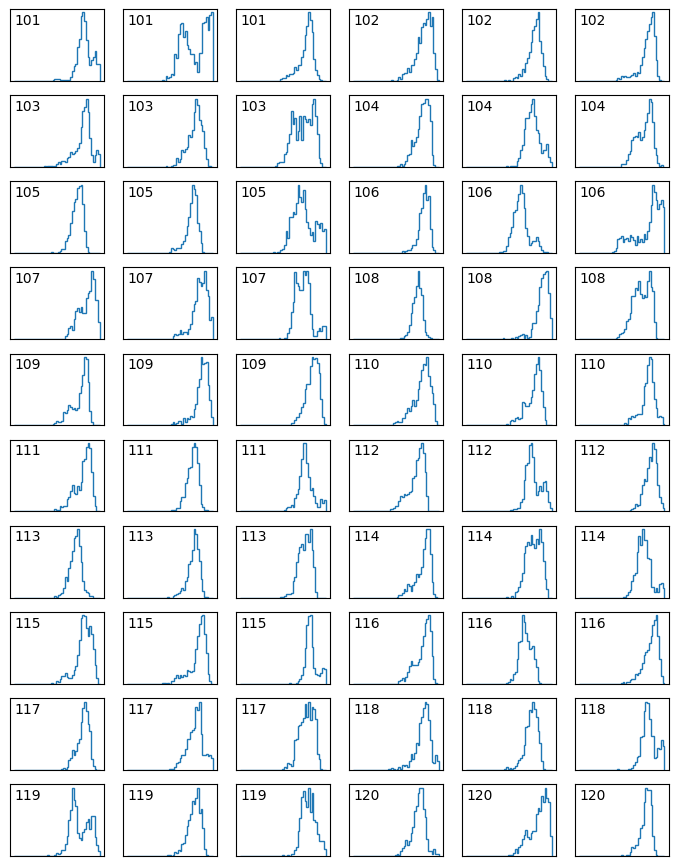

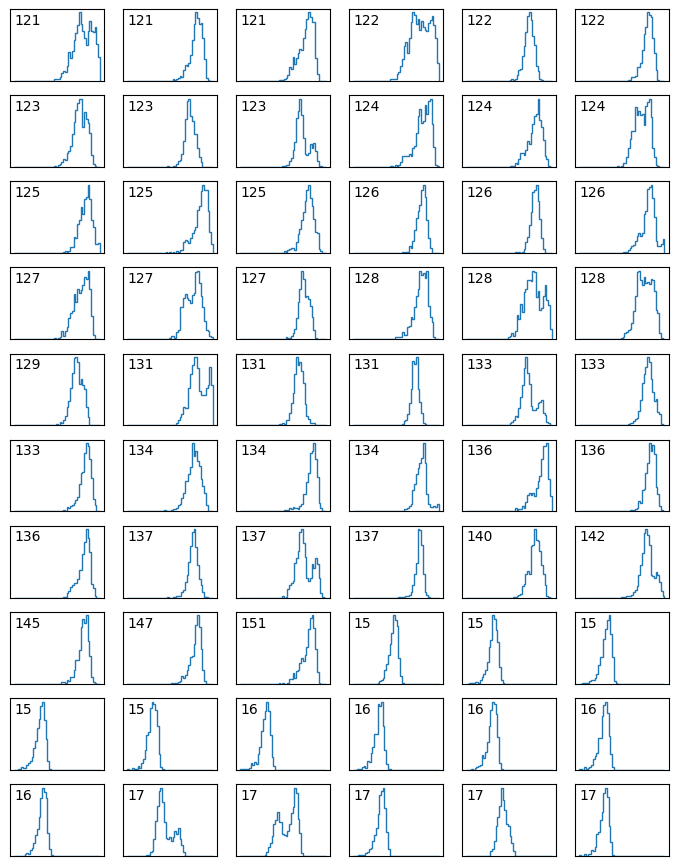

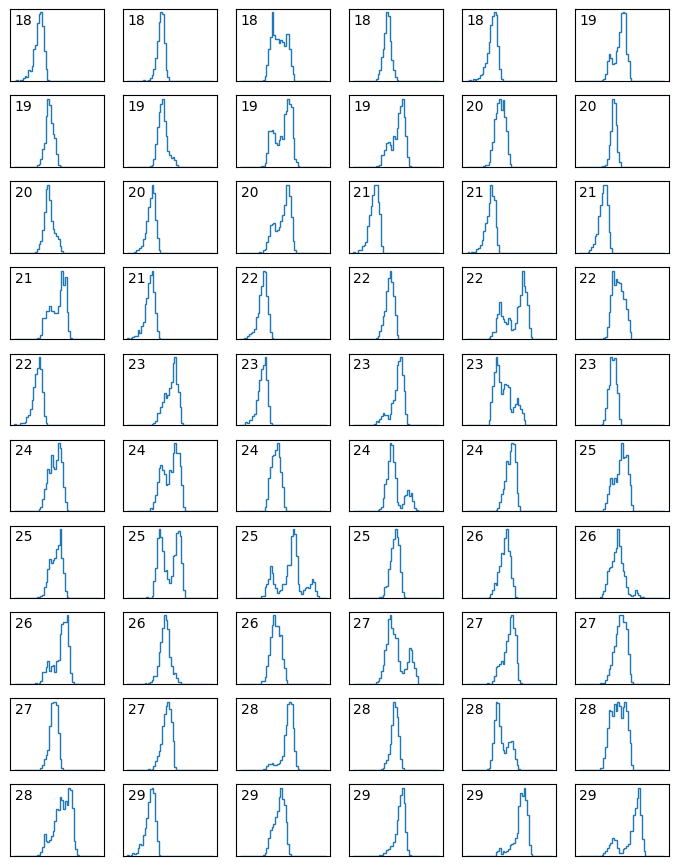

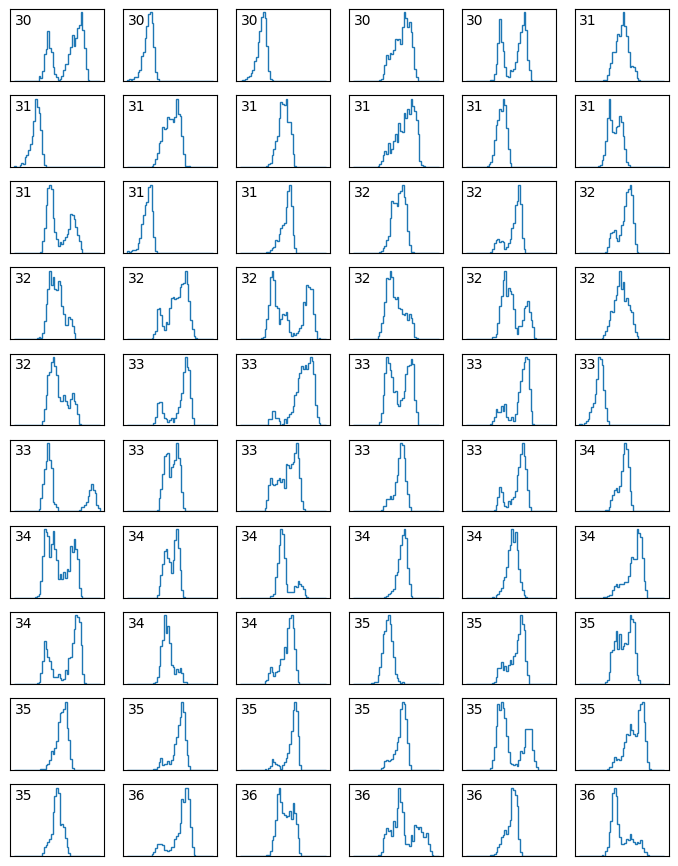

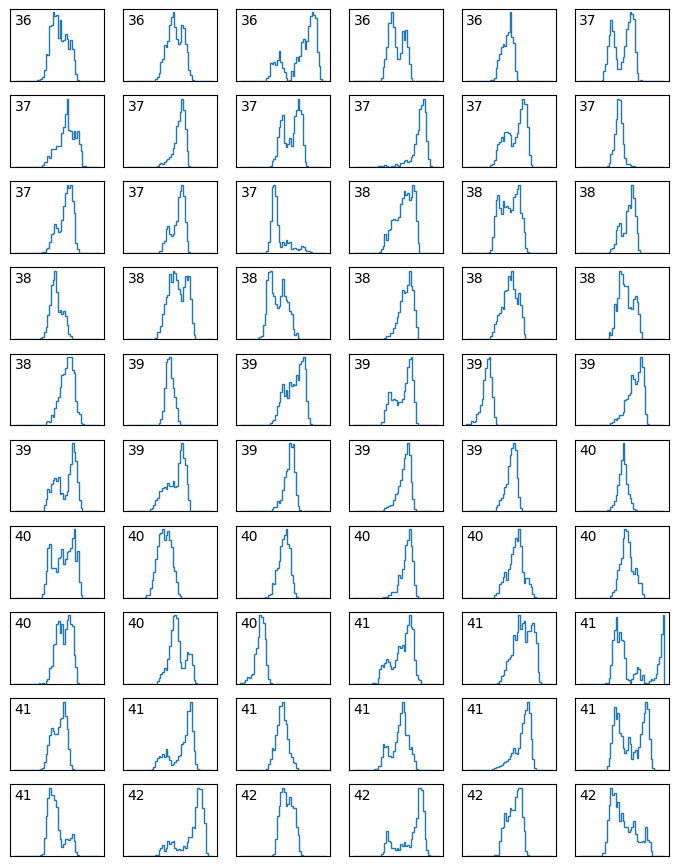

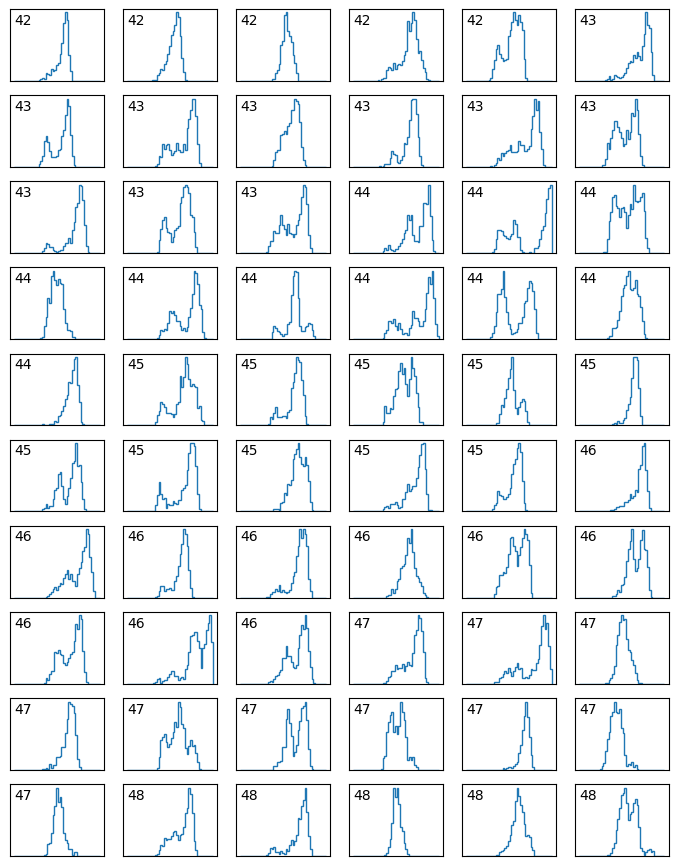

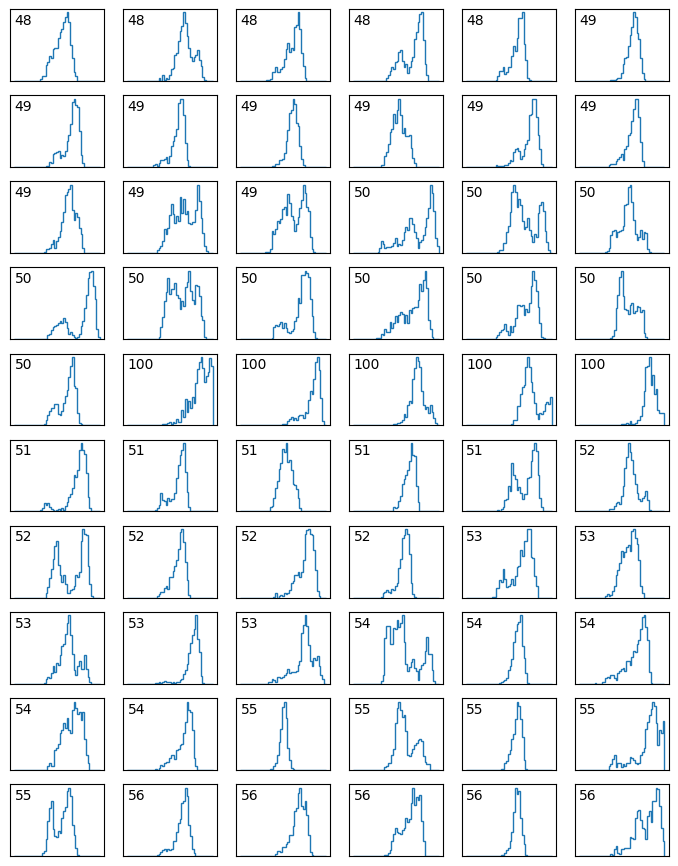

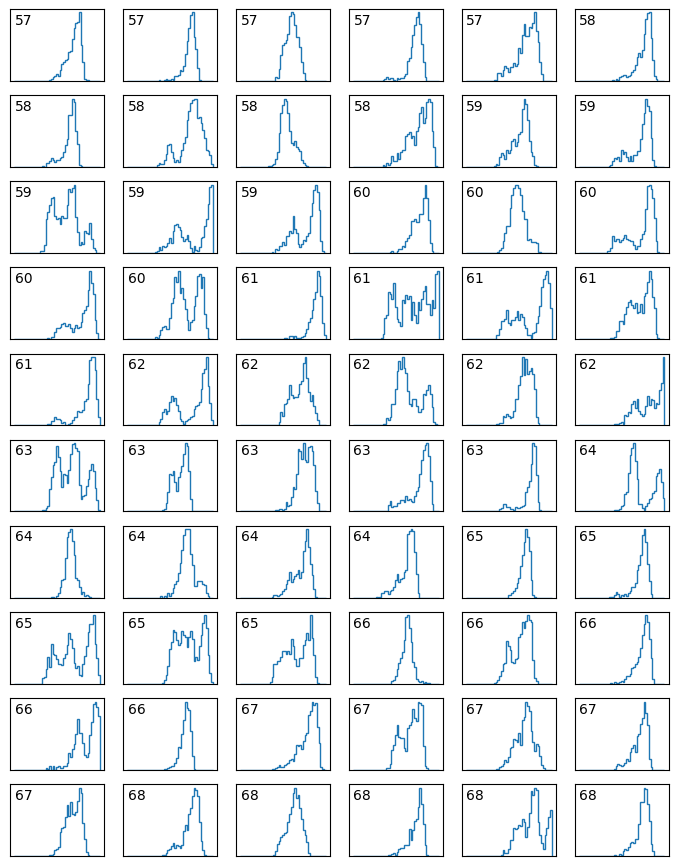

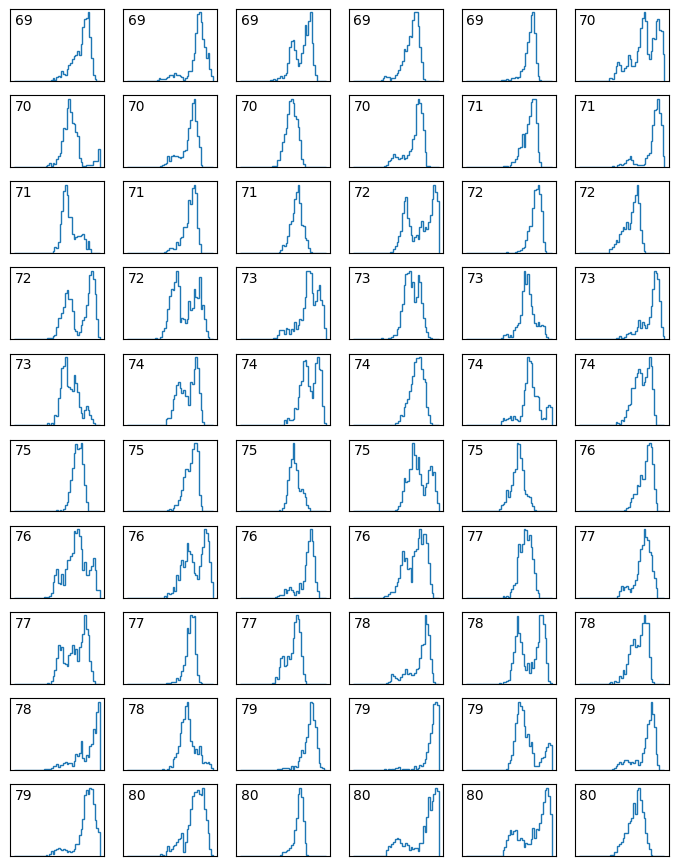

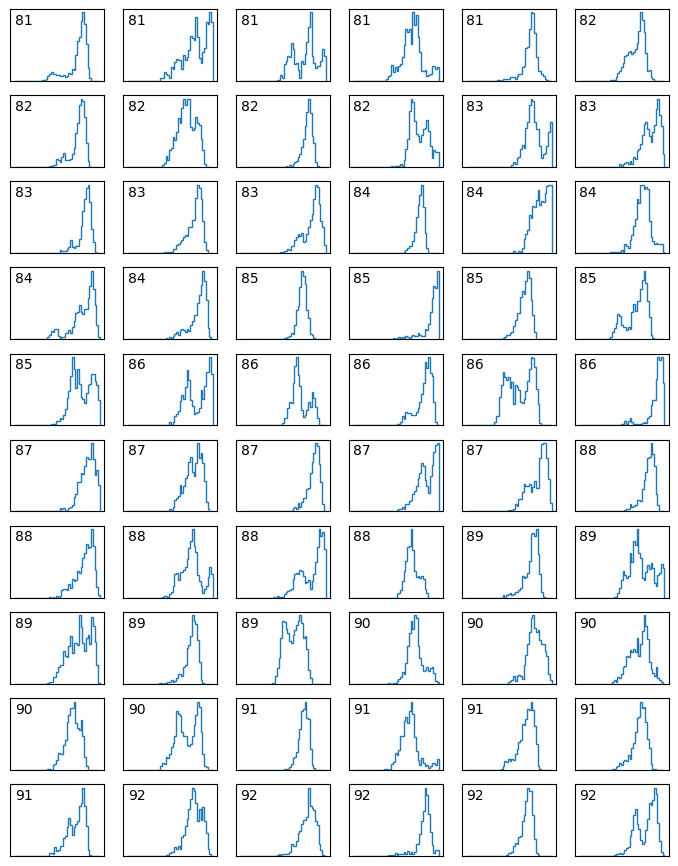

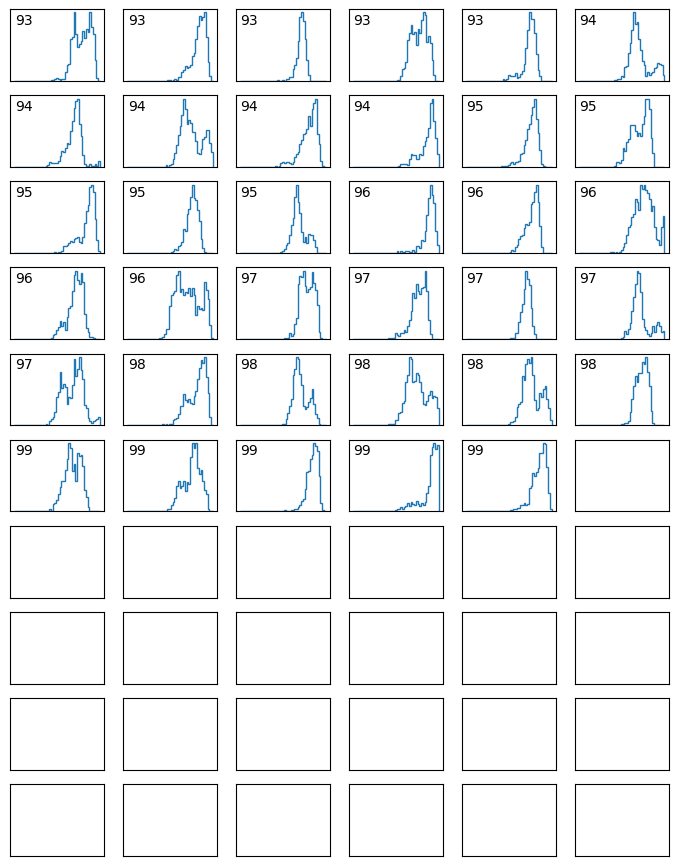

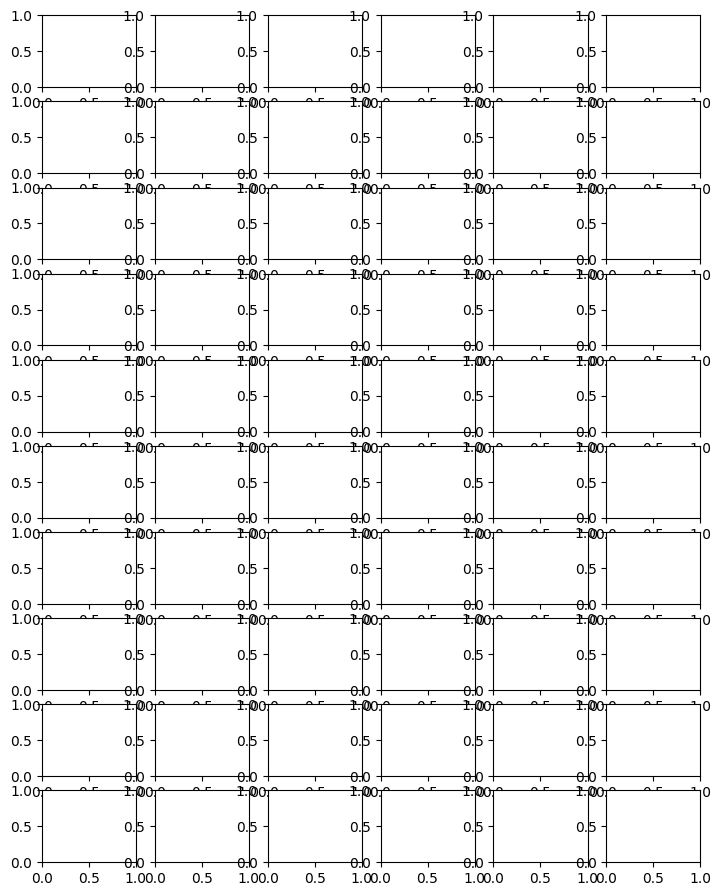

In [61]:
dir = Path('.')

num_bins = 50
binedges_log_fpt = np.linspace(min_log_fpt, max_log_fpt, num_bins)

width_inch = 8.5
height_inch = 11
n_x = 6
n_y = 10
fig, axs = plt.subplots(n_y, n_x, figsize=(width_inch, height_inch))
#plt.tight_layout(pad=1.0)

ax_counter = 0
page_counter = 1
for file in dir.rglob('*'):
    if file.is_file() and file.parent != dir:
        data = np.loadtxt(Path(file).resolve(), delimiter=',', usecols=2)

        where_data_nonzero = np.where(data != 0)[0]
        log_data = np.log(data[where_data_nonzero])
        
        seq = str(np.loadtxt(Path(file).resolve(), delimiter=',', usecols=4, max_rows=1, dtype=str))

        hist_log_fpt, _ = np.histogram(log_data, binedges_log_fpt, density=True)
        
        i_x = ax_counter % n_x
        i_y = int(ax_counter/n_x)

        ax = axs[i_y][i_x]
        ax.stairs(hist_log_fpt, binedges_log_fpt)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.text(0.05, 0.95, str(len(seq)), transform=ax.transAxes, verticalalignment='top')

        ax_counter += 1
        if ax_counter == n_x*n_y:
            plt.savefig(f'hist_log_fpt_{page_counter}.pdf', bbox_inches='tight', pad_inches=0.25)
            ax_counter = 0
            fig, axs = plt.subplots(n_y, n_x, figsize=(width_inch, height_inch))
            page_counter += 1

while True:
    i_x = ax_counter % n_x
    i_y = int(ax_counter/n_x)

    ax = axs[i_y][i_x]
    ax.set_xticks([])
    ax.set_yticks([])
    
    ax_counter += 1
    if ax_counter == n_x*n_y:
        plt.savefig(f'hist_log_fpt_{page_counter}.pdf', bbox_inches='tight', pad_inches=0.25)
        fig, axs = plt.subplots(n_y, n_x, figsize=(width_inch, height_inch))
        break



# 2026-04-21

## Histogram (pdf) vs cdf vs folding characteristic

CUGGUAAGCACUGUGUGAUGGUCCCUUUGGAUCCCACGCAAUCUUCGUGUGUACUAAUUGGAAAGCGCAAAACGAGUAGGGCUCGCGACAAUCGGAAAUU
100


Text(0.05, 0.95, '100')

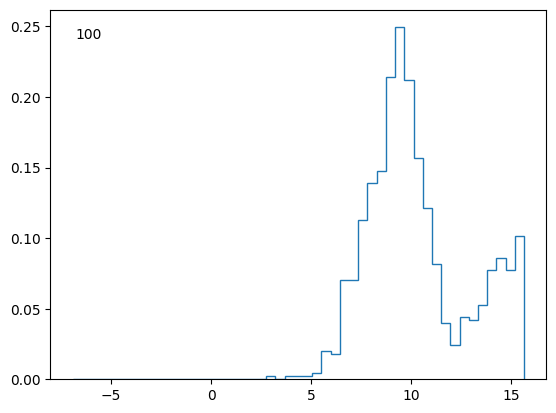

In [74]:
filename = 'long_seq_51_100_nt/length_100/18871197_712_output2024_06_24_03_42_04__0.csv'
data = np.loadtxt(filename, delimiter=',', usecols=2)

where_data_nonzero = np.where(data != 0)[0]
log_data = np.log(data[where_data_nonzero])

seq = str(np.loadtxt(filename, delimiter=',', usecols=4, max_rows=1, dtype=str))
print(seq)
print(len(seq))

hist_log_fpt, _ = np.histogram(log_data, binedges_log_fpt, density=True)

fig, ax = plt.subplots()
ax.stairs(hist_log_fpt, binedges_log_fpt)
ax.text(0.05, 0.95, str(len(seq)), transform=ax.transAxes, verticalalignment='top')


CUGGUAAGCACUGUGUGAUGGUCCCUUUGGAUCCCACGCAAUCUUCGUGUGUACUAAUUGGAAAGCGCAAAACGAGUAGGGCUCGCGACAAUCGGAAAUU
100


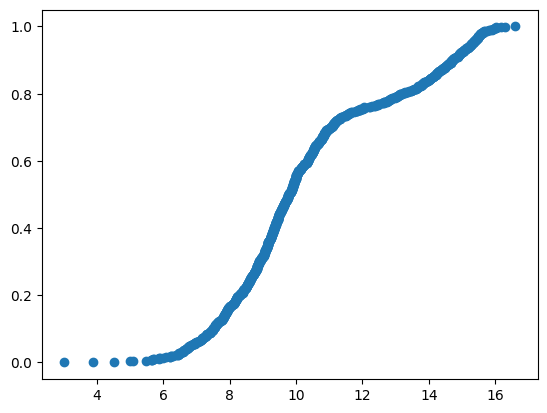

In [75]:
filename = 'long_seq_51_100_nt/length_100/18871197_712_output2024_06_24_03_42_04__0.csv'
data = np.loadtxt(filename, delimiter=',', usecols=2)

where_data_nonzero = np.where(data != 0)[0]
log_data = np.log(data[where_data_nonzero])

seq = str(np.loadtxt(filename, delimiter=',', usecols=4, max_rows=1, dtype=str))
print(seq)
print(len(seq))

#hist_log_fpt, _ = np.histogram(log_data, binedges_log_fpt, density=True)

sort_log_data = np.sort(log_data)
cdf = np.linspace(0,1,sort_log_data.size)

fig, ax = plt.subplots()
plt.scatter(sort_log_data, cdf)

CUGGUAAGCACUGUGUGAUGGUCCCUUUGGAUCCCACGCAAUCUUCGUGUGUACUAAUUGGAAAGCGCAAAACGAGUAGGGCUCGCGACAAUCGGAAAUU
100


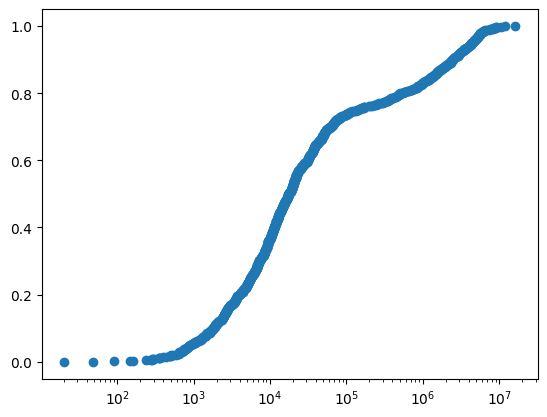

In [82]:
filename = 'long_seq_51_100_nt/length_100/18871197_712_output2024_06_24_03_42_04__0.csv'
data = np.loadtxt(filename, delimiter=',', usecols=2)

where_data_nonzero = np.where(data != 0)[0]
log_data = np.log(data[where_data_nonzero])

seq = str(np.loadtxt(filename, delimiter=',', usecols=4, max_rows=1, dtype=str))
print(seq)
print(len(seq))

#hist_log_fpt, _ = np.histogram(log_data, binedges_log_fpt, density=True)

sort_data = np.sort(data)
cdf = np.linspace(0,1,data.size)

fig, ax = plt.subplots()
plt.scatter(sort_data, cdf)
ax.set_xscale('log')

CUGGUAAGCACUGUGUGAUGGUCCCUUUGGAUCCCACGCAAUCUUCGUGUGUACUAAUUGGAAAGCGCAAAACGAGUAGGGCUCGCGACAAUCGGAAAUU
100


C:\Users\Julius\AppData\Local\Temp\ipykernel_178816\4244363342.py:18: RuntimeWarning: divide by zero encountered in divide
  chi = sort_data * grad_cdf / cdf


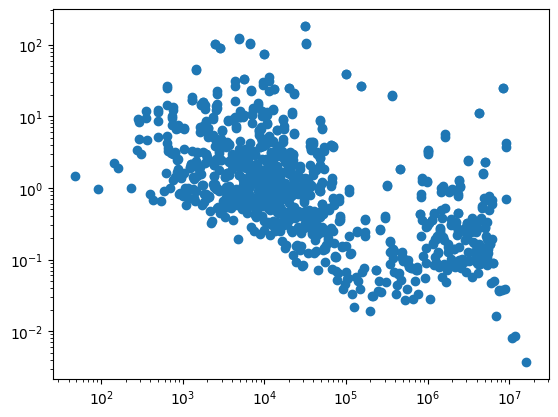

In [84]:
filename = 'long_seq_51_100_nt/length_100/18871197_712_output2024_06_24_03_42_04__0.csv'
data = np.loadtxt(filename, delimiter=',', usecols=2)

where_data_nonzero = np.where(data != 0)[0]
log_data = np.log(data[where_data_nonzero])

seq = str(np.loadtxt(filename, delimiter=',', usecols=4, max_rows=1, dtype=str))
print(seq)
print(len(seq))

#hist_log_fpt, _ = np.histogram(log_data, binedges_log_fpt, density=True)

sort_data = np.sort(data)
cdf = np.linspace(0,1,data.size)
grad_cdf = np.gradient(cdf, sort_data)

# folding characteristic 
chi = sort_data * grad_cdf / cdf

fig, ax = plt.subplots()
plt.scatter(sort_data, chi)
ax.set_xscale('log')
ax.set_yscale('log')

## Median log folding time vs various attributes of sequence

In [107]:
dir = Path('.')

arr_medlogfpt = [] # median log fpt (first passage time)
arr_seqlength = [] # sequence length
arr_gc = [] # gc content (fraction of nucleotides that are 'G' or 'C')
arr_mfe = [] # minimum free energy (mfe)

for file in dir.rglob('*'):
    if file.is_file() and file.parent != dir:
        data = np.loadtxt(Path(file).resolve(), delimiter=',', usecols=2)
        where_data_nonzero = np.where(data != 0)[0]
        log_data = np.log(data[where_data_nonzero])
        seq = str(np.loadtxt(Path(file).resolve(), delimiter=',', usecols=4, max_rows=1, dtype=str))
        gc = (seq.count('G')+seq.count('C'))/len(seq)
        mfe = np.loadtxt(Path(file).resolve(), delimiter=',', usecols=1, max_rows=1)

        arr_medlogfpt.append(np.median(log_data))
        arr_seqlength.append(len(seq))
        arr_gc.append(gc)
        arr_mfe.append(mfe)
        
arr_medlogfpt = np.array(arr_medlogfpt)
arr_seqlength = np.array(arr_seqlength)
arr_gc = np.array(arr_gc)
arr_mfe = np.array(arr_mfe)

In [100]:
def fitline(x, y):
    X = np.vstack((x, np.ones(x.size))).T
    theta = np.linalg.pinv(X.T@X)@X.T@y
    slope = theta[0]
    intercept = theta[1]
    r = slope / (np.std(y) / np.std(x))
    return slope, intercept, r

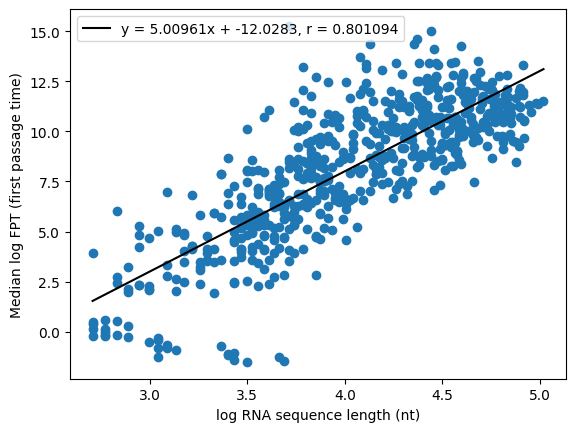

In [102]:
fig, ax = plt.subplots()

ax.set_xlabel('log RNA sequence length (nt)')
ax.set_ylabel('Median log FPT (first passage time)')

arr_logseqlength = np.log(arr_seqlength)
x = arr_logseqlength
y = arr_medlogfpt

ax.scatter(x, y)

slope, intercept, r = fitline(x, y)

ax.plot(np.array([min(x), max(x)]),
        slope*np.array([min(x), max(x)]) + intercept,
        color='black', label=f'y = {slope:.6g}x + {intercept:.6g}, r = {r:.6g}')
ax.legend()

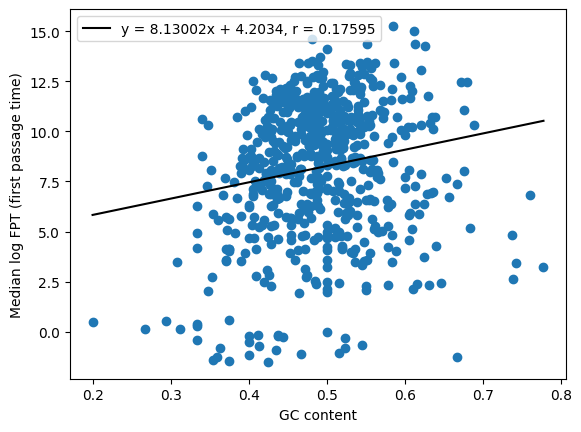

In [104]:
fig, ax = plt.subplots()

ax.set_xlabel('GC content')
ax.set_ylabel('Median log FPT (first passage time)')

x = arr_gc
y = arr_medlogfpt

ax.scatter(x, y)

slope, intercept, r = fitline(x, y)

ax.plot(np.array([min(x), max(x)]),
        slope*np.array([min(x), max(x)]) + intercept,
        color='black', label=f'y = {slope:.6g}x + {intercept:.6g}, r = {r:.6g}')
ax.legend()

C:\Users\Julius\AppData\Local\Temp\ipykernel_178816\1202846873.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


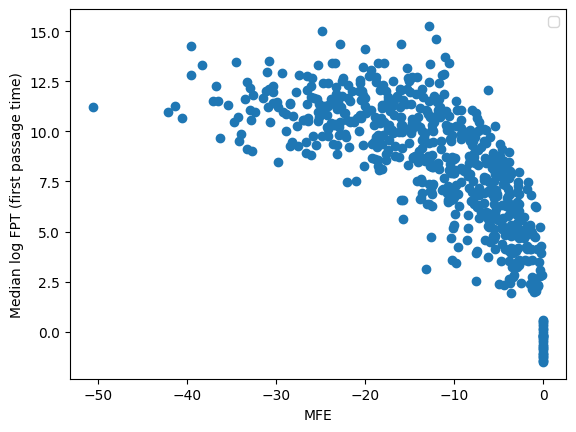

In [109]:
fig, ax = plt.subplots()

ax.set_xlabel('MFE')
ax.set_ylabel('Median log FPT (first passage time)')

x = arr_mfe
y = arr_medlogfpt

ax.scatter(x, y)

slope, intercept, r = fitline(x, y)

# ax.plot(np.array([min(x), max(x)]),
#         slope*np.array([min(x), max(x)]) + intercept,
#         color='black', label=f'y = {slope:.6g}x + {intercept:.6g}, r = {r:.6g}')
ax.legend()

C:\Users\Julius\AppData\Local\Temp\ipykernel_178816\1936699945.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


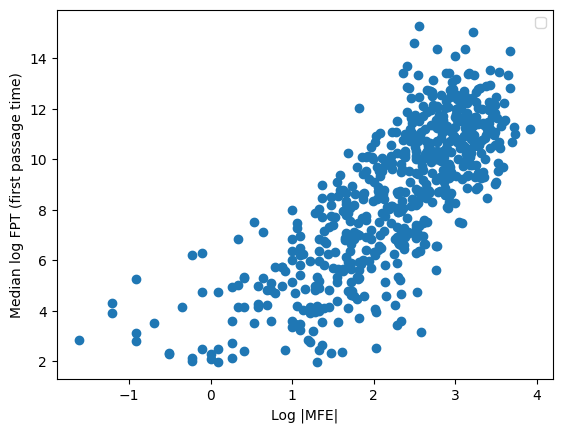

In [113]:
fig, ax = plt.subplots()

ax.set_xlabel('Log |MFE|')
ax.set_ylabel('Median log FPT (first passage time)')

where_mfe_nonzero = np.where(arr_mfe != 0)[0]
x = np.log(np.abs(arr_mfe[where_mfe_nonzero]))
y = arr_medlogfpt[where_mfe_nonzero]

ax.scatter(x, y)

slope, intercept, r = fitline(x, y)

# ax.plot(np.array([min(x), max(x)]),
#         slope*np.array([min(x), max(x)]) + intercept,
#         color='black', label=f'y = {slope:.6g}x + {intercept:.6g}, r = {r:.6g}')
ax.legend()